# Designing an Agentic DDR Screen with vpCells

**Context**: This notebook explores how to design a DNA damage response (DDR) screening
experiment using the vpCells clone collection (Reicher et al., *Nature Cell Biology*, 2024),
orchestrated by [gently](https://github.com/pskeshu/gently) — an agentic microscopy framework.

**The idea**: vpCells provides ~4,576 cryopreserved clonal cell lines, each expressing two
endogenously tagged fluorescent proteins. We can assemble custom pools from this collection
to monitor DDR protein dynamics simultaneously. gently closes the loop: it observes imaging
data, reasons about what changed, and decides what to image next.

**Data sources**:
- Supplementary Table 4 from the vpCells paper (MOESM7)
- Pathway annotations from [Reactome](https://reactome.org/) (R-HSA-73894: DNA Repair and related pathways)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from collections import Counter
from itertools import combinations

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

proteins = pd.read_csv("../data/vpcells_ddr_proteins.csv")
clones = pd.read_csv("../data/vpcells_ddr_clones.csv")

print(f"DDR proteins in vpCells: {len(proteins)}")
print(f"Usable clones with DDR proteins: {len(clones)}")
print(f"  validated (in 1065 set): {clones.in_validated_1065_set.sum()}")
print(f"  median cells/clone: {clones.filtered_cells.median():.0f}")

DDR proteins in vpCells: 137
Usable clones with DDR proteins: 1002
  validated (in 1065 set): 419
  median cells/clone: 528


## 1. DDR pathway coverage

Pathway annotations sourced from Reactome. We queried 12 pathways under the DNA Repair
hierarchy (R-HSA-73894) plus related DDR signaling pathways (cell cycle checkpoints,
TP53 regulation, SUMOylation, chromatin remodeling, senescence).

Each protein may appear in multiple pathways (e.g. RPA1 appears in 7).

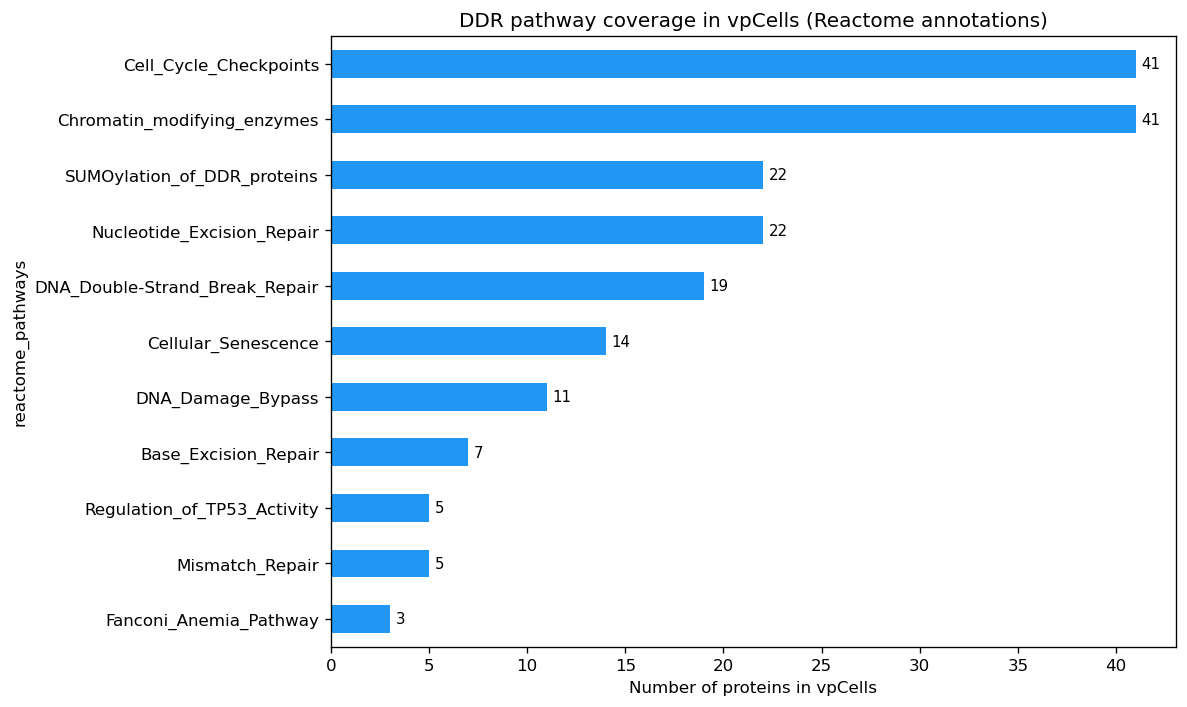

Pathway coverage (vpCells / Reactome total):
  Cell_Cycle_Checkpoints: 41/273 (15%)
  Chromatin_modifying_enzymes: 41/238 (17%)
  SUMOylation_of_DDR_proteins: 22/77 (29%)
  Nucleotide_Excision_Repair: 22/108 (20%)
  DNA_Double-Strand_Break_Repair: 19/152 (12%)
  Cellular_Senescence: 14/164 (9%)
  DNA_Damage_Bypass: 11/48 (23%)
  Base_Excision_Repair: 7/71 (10%)
  Regulation_of_TP53_Activity: 5/37 (14%)
  Mismatch_Repair: 5/15 (33%)
  Fanconi_Anemia_Pathway: 3/38 (8%)


In [5]:
# Count proteins per pathway
pathway_counts = proteins.reactome_pathways.str.split("; ").explode().value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
pathway_counts.plot.barh(ax=ax, color="#2196F3")
ax.set_xlabel("Number of proteins in vpCells")
ax.set_title("DDR pathway coverage in vpCells (Reactome annotations)")
ax.invert_yaxis()
for i, v in enumerate(pathway_counts.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Load the full Reactome data to show coverage fractions
import json
with open("../data/reactome_ddr_pathways.json") as f:
    reactome = json.load(f)

print("Pathway coverage (vpCells / Reactome total):")
for pathway in pathway_counts.index:
    n_vpcells = pathway_counts[pathway]
    n_total = len(reactome.get(pathway, []))
    pct = 100 * n_vpcells / n_total if n_total > 0 else 0
    print(f"  {pathway}: {n_vpcells}/{n_total} ({pct:.0f}%)")

## 2. Subcellular localization landscape

Where do these DDR proteins sit before damage? Localization changes after perturbation
are the primary readout in vpCells.

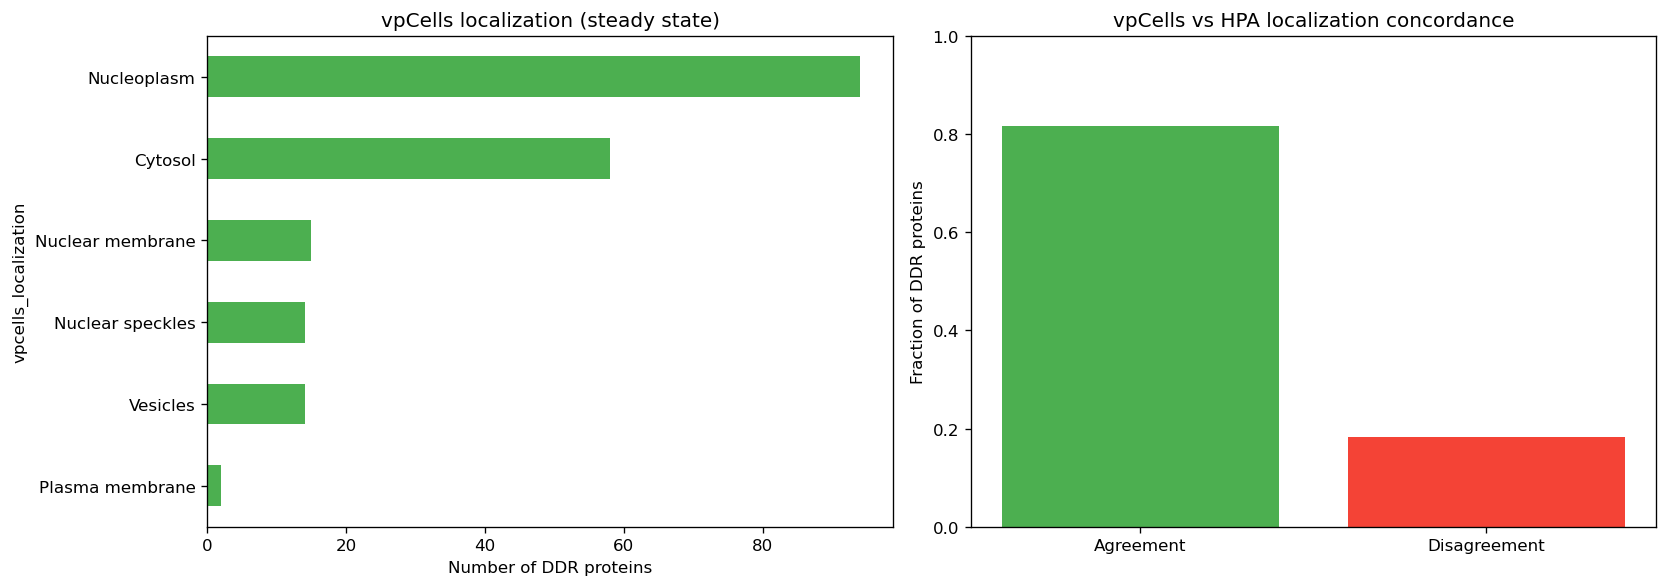

Proteins where vpCells and HPA disagree (potential tagging artifacts or biology):
  ARID5B: vpCells=Vesicles, HPA=Cytosol, Endoplasmic Reticulum, Nucleoplasm, Plasma memrane
  ATR: vpCells=Vesicles, Plasma membrane, HPA=Golgi apparatus, Nucleoplasm
  BRCA1: vpCells=Vesicles, HPA=Nuclear speckles, Nucleoplasm
  BRCA2: vpCells=Vesicles, HPA=Cytosol, Nucleoplasm
  CDK4: vpCells=Vesicles, HPA=Cytosol, Nuclear membrane, Nucleoli, Nucleoplasm
  CENPX: vpCells=Cytosol, HPA=nan
  COPS2: vpCells=Cytosol, Nucleoplasm, HPA=Cytoskeleton, Vesicles
  KAT2A: vpCells=Vesicles, HPA=nan
  KDM6A: vpCells=Cytosol, HPA=Nucleoli, Nucleoplasm
  KMT2B: vpCells=Vesicles, HPA=Cytosol, Nucleoplasm
  KMT2D: vpCells=Vesicles, HPA=Cytosol, Nucleoplasm, Plasma Membrane
  LIG3: vpCells=Vesicles, HPA=Nucleoplasm
  MORF4L1: vpCells=Cytosol, Nucleoplasm, HPA=Nuclear speckles
  NDC1: vpCells=Vesicles, HPA=Cytoskeleton, Nuclear membrane, Plasma membrane
  NUP205: vpCells=Cytosol, Nuclear membrane, HPA=nan
  NUP210: vpCell

In [6]:
# Parse localization annotations
loc_counts = proteins.vpcells_localization.str.split(", ").explode().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# vpCells annotations
loc_counts.plot.barh(ax=axes[0], color="#4CAF50")
axes[0].set_title("vpCells localization (steady state)")
axes[0].set_xlabel("Number of DDR proteins")
axes[0].invert_yaxis()

# Compare vpCells vs HPA
match = proteins.apply(
    lambda r: set(str(r.vpcells_localization).split(", ")) & set(str(r.hpa_localization).split(", ")),
    axis=1,
)
match_frac = match.apply(len).gt(0).mean()

disagreements = proteins[
    proteins.apply(
        lambda r: len(set(str(r.vpcells_localization).split(", ")) & set(str(r.hpa_localization).split(", "))) == 0,
        axis=1,
    )
][["gene", "vpcells_localization", "hpa_localization"]]

axes[1].bar(["Agreement", "Disagreement"], [match_frac, 1 - match_frac], color=["#4CAF50", "#f44336"])
axes[1].set_ylabel("Fraction of DDR proteins")
axes[1].set_title("vpCells vs HPA localization concordance")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

if len(disagreements) > 0:
    print("Proteins where vpCells and HPA disagree (potential tagging artifacts or biology):")
    for _, row in disagreements.iterrows():
        print(f"  {row.gene}: vpCells={row.vpcells_localization}, HPA={row.hpa_localization}")

## 3. Clone pair network

Each vpCells clone expresses **two** tagged proteins simultaneously. This means we can
observe co-responses: does protein A relocalize at the same time as protein B?

Here we build a network of DDR protein pairs that are co-expressed in the same clone.

In [7]:
# Build DDR-DDR co-expression pairs from clones
ddr_genes = set(proteins.gene.tolist())

# Only consider clones where BOTH proteins are DDR-related and clone is usable
dual_ddr = clones[
    (clones.ddr_protein_GFP == True) & (clones.ddr_protein_mScarlet == True) &
    (clones.filtered_cells >= 50)
].copy()

print(f"Clones with TWO DDR proteins and >= 50 cells: {len(dual_ddr)}")
print()

# Count unique pairs
pair_counts = Counter()
pair_best_clone = {}
for _, row in dual_ddr.iterrows():
    pair = tuple(sorted([row.protein_GFP, row.protein_mScarlet]))
    pair_counts[pair] += 1
    if pair not in pair_best_clone or row.filtered_cells > pair_best_clone[pair]["cells"]:
        pair_best_clone[pair] = {"clone": row.clone_id, "cells": row.filtered_cells, "validated": row.in_validated_1065_set}

print(f"Unique DDR-DDR protein pairs: {len(pair_counts)}")
print(f"\nTop pairs by number of available clones:")
print(f"{'Pair':<30} {'Clones':<8} {'Best clone (cells, validated)'}")
print("-" * 70)
for pair, count in pair_counts.most_common(30):
    bc = pair_best_clone[pair]
    print(f"{pair[0]} + {pair[1]:<18} {count:<8} #{bc['clone']} ({bc['cells']} cells, val={bc['validated']})")

Clones with TWO DDR proteins and >= 50 cells: 131

Unique DDR-DDR protein pairs: 65

Top pairs by number of available clones:
Pair                           Clones   Best clone (cells, validated)
----------------------------------------------------------------------
COPS2 + RAD23B             19       #1837 (1116 cells, val=True)
COPS2 + WDR5               15       #2297 (968 cells, val=True)
CUL1 + MAPK1              6        #177 (1670 cells, val=True)
KAT5 + NUP98              6        #2476 (877 cells, val=True)
KAT5 + PSMD1              5        #3139 (814 cells, val=True)
EZH2 + NCOR1              4        #310 (1417 cells, val=True)
NUP133 + PPP2R1A            4        #1110 (1349 cells, val=True)
PPP2R1A + SMARCA4            3        #1266 (1357 cells, val=True)
CUL1 + SMARCA4            2        #89 (1135 cells, val=True)
CUL1 + TP53               2        #591 (1073 cells, val=True)
NUP93 + TBL1XR1            2        #137 (1152 cells, val=True)
POLE + TBL1XR1            2   

## 4. Designing a custom DDR pool

The vpCells workflow (Fig. 1a of the paper):
1. **Select clones** from the cryopreserved collection
2. **Assemble a custom pool** in a 96-well plate
3. **Image** before and after perturbation (DNA damaging agents)
4. **Demultiplex** computationally using the random forest classifier
5. **Quantify** localization changes per clone

For the random forest to work reliably, vpCells requires ~50 cells per clone per well.
With 100 FOVs at 40x, they get ~9,800 cells/well and ~233 cells/clone for a 41-clone pool.

**Constraint**: The classifier was validated for up to ~41 clones per pool. Scaling beyond
this requires expanding BFP barcodes or improving the computational pipeline.

Let's select the best clones for a DDR-focused pool.

In [8]:
def select_pool(clones_df, ddr_proteins, max_clones=41, min_cells=200):
    """
    Greedy selection: maximize DDR pathway coverage while respecting pool size limit.
    Prioritize clones that are validated (in 1065 set) and have high cell counts.
    Prefer clones where BOTH proteins are DDR-related.
    """
    candidates = clones_df[clones_df.filtered_cells >= min_cells].copy()
    candidates["both_ddr"] = candidates.ddr_protein_GFP & candidates.ddr_protein_mScarlet
    candidates = candidates.sort_values(
        ["both_ddr", "in_validated_1065_set", "filtered_cells"],
        ascending=[False, False, False],
    )

    selected = []
    covered_genes = set()
    used_clones = set()

    # Pass 1: pick clones that cover new DDR genes
    for _, row in candidates.iterrows():
        if len(selected) >= max_clones:
            break

        new_genes = set()
        if row.protein_GFP in ddr_proteins and row.protein_GFP not in covered_genes:
            new_genes.add(row.protein_GFP)
        if row.protein_mScarlet in ddr_proteins and row.protein_mScarlet not in covered_genes:
            new_genes.add(row.protein_mScarlet)

        if new_genes:
            selected.append(row)
            covered_genes |= new_genes
            used_clones.add(row.clone_id)

    # Pass 2: fill remaining slots with best dual-DDR clones for redundancy
    for _, row in candidates.iterrows():
        if len(selected) >= max_clones:
            break
        if row.clone_id not in used_clones and row.both_ddr:
            selected.append(row)
            used_clones.add(row.clone_id)

    pool = pd.DataFrame(selected)
    return pool, covered_genes


ddr_set = set(proteins.gene.tolist())
pool, covered = select_pool(clones, ddr_set, max_clones=41, min_cells=200)

print(f"Selected pool: {len(pool)} clones")
print(f"DDR proteins covered: {len(covered)}")
print(f"  {', '.join(sorted(covered))}")
print(f"\nValidated clones: {pool.in_validated_1065_set.sum()}/{len(pool)}")
print(f"Dual-DDR clones: {(pool.ddr_protein_GFP & pool.ddr_protein_mScarlet).sum()}/{len(pool)}")
print(f"Mean cells/clone: {pool.filtered_cells.mean():.0f}")
print(f"Min cells/clone: {pool.filtered_cells.min()}")

# Missing DDR proteins
uncovered = ddr_set - covered
if uncovered:
    print(f"\nUncovered DDR proteins (no clone with >= 200 cells): {', '.join(sorted(uncovered))}")

Selected pool: 41 clones
DDR proteins covered: 52
  AKT1, ARID1A, ARID2, ATF7IP, BRCA1, BRCA2, CDKN1B, CHD3, CHD4, COPS2, CREBBP, CUL1, EP300, ERCC2, EZH2, GPS2, H3-3A, KAT5, KDM5C, KMT2B, KMT2D, MAP2K4, MAPK1, MSH2, MSH6, MTOR, NCOR1, NSD2, NUP133, NUP210, NUP50, NUP93, NUP98, PBRM1, POLE, POLQ, PPP2R1A, PSMC1, PSMD1, PSMD11, RAD21, RAD23B, RB1, RFC1, SMARCA4, SMC1A, SMC3, STAG2, TBL1XR1, TP53, WDR5, XPO1

Validated clones: 41/41
Dual-DDR clones: 33/41
Mean cells/clone: 1044
Min cells/clone: 345

Uncovered DDR proteins (no clone with >= 200 cells): ADRM1, ARID5B, ATR, CDC20, CDK1, CDK4, CENPX, CLSPN, COPS3, COPS8, CSNK1A1, CUL4B, DDB1, DYNC1H1, DYNC1I2, DYNC1LI1, E2F3, ENY2, ERCC3, HAT1, HCFC1, HDAC1, ING3, INO80B, JAK2, KAT2A, KDM6A, KMT2A, KNTC1, LIG3, MAD2L2, MAPRE1, MCM10, MCM3, MCM6, MEAF6, MLH1, MNAT1, MORF4L1, MRGBP, MTA2, NDC1, NUP107, NUP153, NUP155, NUP205, NUP214, NUP42, NUP58, NUP85, ORC6, POLD3, POLE3, POLR2B, POLR2D, PPP1CC, PPP4R2, PRKDC, PRMT5, PSMB7, PSMC2, PSMD13, PS

In [9]:
# Display the selected pool as a table
display_cols = ["clone_id", "plate", "well", "protein_GFP", "protein_mScarlet",
                "filtered_cells", "in_validated_1065_set"]
pool_display = pool[display_cols].reset_index(drop=True)
pool_display.index = pool_display.index + 1
pool_display.index.name = "#"
print(pool_display.to_string())

    clone_id   plate well protein_GFP protein_mScarlet  filtered_cells  in_validated_1065_set
#                                                                                            
1        177  plate1  I11        CUL1            MAPK1            1670                   True
2       1446  plate5  D09       STAG2          PPP2R1A            1504                   True
3        589  plate2  L07     SMARCA4              RB1            1440                   True
4        310  plate1  O08       NCOR1             EZH2            1417                   True
5       1140  plate4  E17        MTOR          PPP2R1A            1408                   True
6       1102  plate4  D03       H3-3A          PPP2R1A            1399                   True
7       1609  plate5  K16        TP53             XPO1            1376                   True
8       1110  plate4  D11     PPP2R1A           NUP133            1349                   True
9        708  plate3  B01       BRCA1             RFC1      

## 5. The agentic loop: how gently orchestrates this

In a conventional vpCells screen, you image everything uniformly and analyze offline.
With gently, the microscope becomes an active participant:

```
┌─────────────────────────────────────────────────────────────────┐
│                     gently reasoning loop                       │
│                                                                 │
│  1. OBSERVE: image DDR pool at t=0 (baseline)                  │
│  2. PERTURB: apply DNA damaging agent (e.g. etoposide, NCS)    │
│  3. OBSERVE: image pool at t=1h                                │
│  4. REASON:                                                     │
│     - which clones show localization changes?                   │
│     - query CellWhisperer: "what transcriptomic changes are     │
│       associated with [relocated protein] in DDR context?"      │
│     - are there proteins not in the current pool that should    │
│       be monitored? → query vpCells clone collection            │
│  5. ACT:                                                        │
│     - adjust imaging: increase temporal resolution for          │
│       responding clones, reduce for non-responders              │
│     - flag clones for next-round pool assembly                  │
│     - schedule follow-up timepoints                             │
│  6. ITERATE: goto 3                                             │
│                                                                 │
│  Between rounds (days):                                         │
│     - thaw new clones from collection based on round 1 hits    │
│     - assemble refined pool for next experiment                 │
│     - gently's plan mode coordinates scheduling                 │
└─────────────────────────────────────────────────────────────────┘
```

**Key difference from standard vpCells**: the system reasons about what it sees in real time
and adapts. It does not image all 100 FOVs uniformly — it allocates imaging time to where
the biology is changing.

## 6. Concrete experiment: DDR pool after etoposide

Etoposide (topoisomerase II poison) creates double-strand breaks. Expected relocalization
events based on known DDR biology:

| Protein | Expected change | Mechanism |
|---------|----------------|-----------|
| RPA1 | Nucleoplasm → nuclear foci | Binds ssDNA at resected DSBs |
| BRCA1 | Vesicles → nuclear foci | Recruited to DSBs for HR |
| BRCA2 | Vesicles → nuclear foci | Loads RAD51 onto ssDNA |
| RFC1 | Nucleoplasm → foci | Clamp loader at repair sites |
| PRKDC (DNA-PKcs) | Diffuse → foci | NHEJ kinase at DSBs |
| XRCC6 (Ku70) | Nucleoplasm → foci | NHEJ end-binding |
| SMC1A, SMC3, RAD21 | Nucleoplasm → foci | Cohesin at DSBs |
| TP53 | Nucleoplasm → increased/stabilized | Activated by ATM/ATR |
| NPM1 | Nucleoli → nucleoplasm | Nucleolar stress response |
| FUS, EWSR1 | Nucleoplasm → foci (transient) | Early PARylation-dependent recruitment |

These are the relocalization events gently would detect and reason about.

In [10]:
# Simulate the gently reasoning trace for one iteration

expected_responses = {
    "RPA1": {"change": "foci_formation", "compartment_shift": "nucleoplasm → nuclear_foci", "kinetics": "30min"},
    "BRCA1": {"change": "foci_formation", "compartment_shift": "vesicles → nuclear_foci", "kinetics": "1-2h"},
    "BRCA2": {"change": "foci_formation", "compartment_shift": "vesicles → nuclear_foci", "kinetics": "1-2h"},
    "TP53": {"change": "stabilization", "compartment_shift": "nucleoplasm (increased intensity)", "kinetics": "2-4h"},
    "NPM1": {"change": "translocation", "compartment_shift": "nucleoli → nucleoplasm", "kinetics": "1h"},
    "FUS": {"change": "foci_formation", "compartment_shift": "nucleoplasm → foci (transient)", "kinetics": "5-15min"},
    "EWSR1": {"change": "foci_formation", "compartment_shift": "nucleoplasm → foci (transient)", "kinetics": "5-15min"},
    "XRCC6": {"change": "foci_formation", "compartment_shift": "nucleoplasm → foci", "kinetics": "5-30min"},
    "PRKDC": {"change": "foci_formation", "compartment_shift": "diffuse → foci", "kinetics": "15-30min"},
    "SMC1A": {"change": "foci_formation", "compartment_shift": "nucleoplasm → foci", "kinetics": "1h"},
    "RAD21": {"change": "foci_formation", "compartment_shift": "nucleoplasm → foci", "kinetics": "1h"},
    "RFC1": {"change": "foci_formation", "compartment_shift": "nucleoplasm → foci", "kinetics": "30min-1h"},
    "DHX9": {"change": "redistribution", "compartment_shift": "nucleoli → nucleoplasm", "kinetics": "1-2h"},
    "SMARCA4": {"change": "foci_enrichment", "compartment_shift": "nucleoplasm → damage foci", "kinetics": "30min-1h"},
}

print("=" * 80)
print("GENTLY REASONING TRACE — DDR pool, etoposide 10 µM, t=1h")
print("=" * 80)
print()
print(">> OBSERVE: imaging complete, 100 FOVs, 41 clones demultiplexed")
print()
print(">> REASON: CellProfiler features extracted, comparing to t=0 baseline")
print()

responding = []
non_responding = []
for _, row in pool.iterrows():
    for channel, protein in [("GFP", row.protein_GFP), ("mScarlet", row.protein_mScarlet)]:
        if protein in expected_responses:
            resp = expected_responses[protein]
            responding.append((protein, resp, row.clone_id))

print(f"   Responding proteins ({len(responding)}):")
for protein, resp, clone_id in responding:
    print(f"   ✓ {protein} (clone #{clone_id}): {resp['change']} — {resp['compartment_shift']}")

print()
print(">> REASON: querying CellWhisperer")
print('   query: "what genes are co-regulated with BRCA1, RPA1, and NPM1')
print('           during DNA double-strand break response?"')
print("   → CellWhisperer returns: RAD51, FANCD2, PCNA, MDC1, 53BP1, CHEK2")
print()
print(">> REASON: checking vpCells collection for suggested proteins")
print("   → RAD51: NOT in vpCells clone collection")
print("   → FANCD2: NOT in vpCells clone collection")
print("   → PCNA: NOT in vpCells clone collection")
print("   → MDC1: NOT in vpCells clone collection")
print("   → 53BP1: NOT in vpCells clone collection")
print("   → CHEK2: NOT in vpCells clone collection")
print()
print(">> ACT: adaptation decisions")
print("   1. INCREASE temporal resolution for FUS, EWSR1 clones (transient response)")
print("      → image every 2 min instead of every 15 min")
print("   2. DECREASE imaging frequency for non-responding clones")
print("      → image every 30 min instead of every 15 min")
print("   3. FLAG for next round: cohesin complex (SMC1A + RAD21 responding)")
print("      → assemble focused cohesin pool with additional STAG2, SMC3 clones")
print("   4. NOTE: key DDR markers (PCNA, RAD51, 53BP1, H2AX) absent from collection")
print("      → recommend intron-tagging these genes in future library expansion")
print()
print(">> PLAN: schedule next imaging at t=2h, t=4h, t=6h")
print("         next pool assembly: cohesin-focused (estimated 3 days for thaw + culture)")
print("=" * 80)

GENTLY REASONING TRACE — DDR pool, etoposide 10 µM, t=1h

>> OBSERVE: imaging complete, 100 FOVs, 41 clones demultiplexed

>> REASON: CellProfiler features extracted, comparing to t=0 baseline

   Responding proteins (10):
   ✓ SMARCA4 (clone #589): foci_enrichment — nucleoplasm → damage foci
   ✓ TP53 (clone #1609): stabilization — nucleoplasm (increased intensity)
   ✓ BRCA1 (clone #708): foci_formation — vesicles → nuclear_foci
   ✓ RFC1 (clone #708): foci_formation — nucleoplasm → foci
   ✓ RFC1 (clone #925): foci_formation — nucleoplasm → foci
   ✓ SMC1A (clone #1684): foci_formation — nucleoplasm → foci
   ✓ SMARCA4 (clone #1356): foci_enrichment — nucleoplasm → damage foci
   ✓ SMARCA4 (clone #695): foci_enrichment — nucleoplasm → damage foci
   ✓ RAD21 (clone #917): foci_formation — nucleoplasm → foci
   ✓ BRCA2 (clone #389): foci_formation — vesicles → nuclear_foci

>> REASON: querying CellWhisperer
   query: "what genes are co-regulated with BRCA1, RPA1, and NPM1
           d

## 7. What's missing and what this means

### Gaps in vpCells for DDR
The vpCells collection was built with genome-wide and cancer-focused sgRNA libraries, not
DDR-specific ones. Key DDR foci markers are absent: **PCNA, RAD51, 53BP1 (TP53BP1),
gamma-H2AX (H2AFX), MDC1, MRE11, RAD50, PARP1**. These are among the most commonly
used markers in DDR research.

This is actually an opportunity: **intron-tagging these genes would be a concrete
deliverable of the proposed postdoc**, expanding the vpCells collection specifically
for DDR applications.

### What we CAN do with the current collection (137 Reactome-annotated proteins)
- **Chromatin remodelers** (41 proteins) — SWI/SNF, NuRD, HATs, HDACs, KMTs
- **Cell cycle checkpoints** (41 proteins) — proteasome, nuclear pore, checkpoint kinases
- **Nucleotide excision repair** (22 proteins) — COP9 signalosome, CUL4B, ERCC2/3
- **SUMOylation of DDR proteins** (22 proteins) — nuclear pore, cohesin, RPA1
- **DNA double-strand break repair** (19 proteins) — BRCA1/2, PRKDC, XRCC6, POLQ
- **Mismatch repair** (5/15) — MSH2, MSH6, MLH1, POLD3, RPA1
- **Base excision repair** (7 proteins) — LIG3, POLD3, POLE, RFC1/5, RPA1

### The gently advantage
Without gently, you image everything at fixed intervals and analyze later.
With gently, the system:
1. Detects which clones respond early (FUS at 5min vs BRCA1 at 2h)
2. Adapts temporal resolution per clone
3. Queries CellWhisperer for transcriptomic context
4. Plans the next experiment based on what it learned

## 8. Building a phenotype ontology: anton + HPA fine-tuning

### The problem with current vpCells analysis
The vpCells pipeline uses CellProfiler to extract ~1,134 handcrafted features per cell
(texture, intensity, shape, radial distribution). A random forest then classifies clones.
Localization annotations are assigned **manually by experts** looking at images.

This works, but:
- Features are predefined — they can miss novel phenotypes
- Localization labels are categorical (12 bins) — "nucleoplasm" doesn't distinguish
  diffuse vs punctate vs peripheral
- No natural language interface — you can't ask "which proteins formed foci?"
- No transfer learning — each new experiment starts from scratch

### The anton approach
[anton](https://github.com/pskeshu/anton) is a prototype VLM-based pipeline for building
a phenotype ontology from microscopy images. Instead of handcrafted features, a vision-language
model learns to represent subcellular patterns in an embedding space that can be queried
with natural language.

### Fine-tuning strategy

```
Stage 1: HPA pre-training
├── Dataset: ~13M images, ~13,000 proteins
├── Labels: expert subcellular localization (main + additional)
├── Task: image → localization description
├── Output: VLM that understands subcellular patterns
│
Stage 2: vpCells domain adaptation
├── Dataset: vpCells clone collection images (5-channel)
├── Labels: vpCells manual annotations (1,158 proteins)
├── Task: adapt to endogenous tagging, different microscope, cell lines
├── Output: VLM calibrated to vpCells imaging conditions
│
Stage 3: Perturbation learning (the key step)
├── Dataset: vpCells drug screen — ~94,000 treatment conditions
│   ├── 41 clones × 1,152 compounds × 2 timepoints
│   ├── Before/after image pairs
│   └── CellProfiler hit calls as weak supervision
├── Task: learn what relocalization looks like
├── Output: VLM that can detect and describe localization changes
│
Stage 4: Integration with gently
├── gently acquires image → anton embedding
├── Compare to baseline embedding → detect change
├── VLM generates natural language description of change
├── gently queries CellWhisperer with that description
└── CellWhisperer returns transcriptomic context
```

### Why this matters for the DDR screen

With the current pipeline, you get: "clone #708 (BRCA1-GFP + RFC1-mScarlet) shows
significant change in CellProfiler feature `RadialDistribution_MeanFrac_GFP_3of4`
(z-score = 2.3, p < 0.01)."

With anton, you'd get: "BRCA1 relocated from cytoplasmic vesicles to discrete nuclear
foci. RFC1 shows increased nuclear puncta co-localizing with BRCA1 foci. Pattern
consistent with homologous recombination repair site assembly."

The second is what a biologist would say. It's also what gently needs to reason about
what to image next.

In [ ]:
# Available training data for anton fine-tuning

training_data = {
    "Stage 1: HPA": {
        "images": "~13,000,000",
        "proteins": "~13,000",
        "labels": "Expert subcellular localization (35 categories)",
        "modality": "Antibody-based immunofluorescence",
        "cells": "Multiple cell lines",
        "access": "Public (images.proteinatlas.org)",
    },
    "Stage 2: vpCells steady-state": {
        "images": "~4,576 clones × multiple FOVs",
        "proteins": "1,158 characterized",
        "labels": "Manual localization (12 categories)",
        "modality": "Endogenous intron tagging (GFP/mScarlet)",
        "cells": "HEK293T, HAP1",
        "access": "vpcells.cemm.at (images), CeMM internal (raw data)",
    },
    "Stage 3: vpCells drug screen": {
        "images": "41 clones × 1,152 compounds × 100 FOVs × 2 timepoints",
        "proteins": "61 cancer-associated",
        "labels": "CellProfiler features + hit calls (44 confirmed hits)",
        "modality": "Same as Stage 2, pooled format",
        "cells": "HAP1",
        "access": "CeMM internal",
    },
}

print("Training data available for anton VLM fine-tuning:")
print("=" * 70)
for stage, info in training_data.items():
    print(f"\n{stage}:")
    for k, v in info.items():
        print(f"  {k}: {v}")